# Day 1-3 Exercise: Car Purchase Amount Prediction
### Student Assignment Submission | Machine Learning Regression Pipeline

**Problem Type:** Supervised Regression  
**Target Variable ($y$):** Car Purchase Amount  
**Input Features ($X$):** Gender, Age, Annual Salary, Credit Card Debt, Net Worth

In [5]:
# Importing all required core, visualization, and ML pipeline components
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

# Apply clear visual styling for our inline charts
sns.set_theme(style="whitegrid")

# Task A1: Load the Excel dataset file
# Ensure 'Car_Purchasing_Data.xlsx' is inside your opened VS Code folder!
df = pd.read_excel("Car_Purchasing_Data.xlsx")
print(">>> Dataset successfully loaded into VS Code! <<<")

>>> Dataset successfully loaded into VS Code! <<<


In [4]:
%pip install pandas numpy openpyxl scikit-learn matplotlib seaborn joblib


  Using cached openpyxl-3.1.5-py2.py3-none-any.whl.metadata (2.5 kB)
  Using cached scikit_learn-1.8.0-cp314-cp314-win_amd64.whl.metadata (11 kB)
  Using cached matplotlib-3.10.9-cp314-cp314-win_amd64.whl.metadata (52 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached et_xmlfile-2.0.0-py3-none-any.whl.metadata (2.7 kB)
  Using cached scipy-1.17.1-cp314-cp314-win_amd64.whl.metadata (60 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp314-cp314-win_amd64.whl.metadata (121 kB)
  Using cached kiwisolver-1.5.0-cp314-cp314-win_amd64.whl.metadata (5.2 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached openpyxl-3.1.5-py2.py3-none-any.whl (250 kB)
Using cached scikit_learn-1.

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
print("--- First 5 Rows of Data ---")
print(df.head(), "\n")

print("--- Dataset Structural Shape ---")
print(f"Total Rows: {df.shape[0]} | Total Columns: {df.shape[1]}\n")

print("--- Data Types and Structural Info ---")
df.info()
print("\n")

print("--- Missing Values Check ---")
print(df.isnull().sum(), "\n")

print("--- Duplicate Records Check ---")
print(f"Total Duplicate Rows Found: {df.duplicated().sum()}\n")

print("--- Summary Statistics ---")
print(df.describe())

--- First 5 Rows of Data ---
     Customer Name                                    Customer e-mail Country  \
0    Martina Avila  cubilia.Curae.Phasellus@quisaccumsanconvallis.edu     USA   
1    Harlan Barnes                                eu.dolor@diam.co.uk     USA   
2  Naomi Rodriquez  vulputate.mauris.sagittis@ametconsectetueradip...     USA   
3  Jade Cunningham                            malesuada@dignissim.com     USA   
4     Cedric Leach     felis.ullamcorper.viverra@egetmollislectus.net     USA   

   Gender  Age  Annual Salary  Credit Card Debt    Net Worth  \
0       0   42    62812.09301      11609.380910  238961.2505   
1       0   41    66646.89292       9572.957136  530973.9078   
2       1   43    53798.55112      11160.355060  638467.1773   
3       1   58    79370.03798      14426.164850  548599.0524   
4       1   57    59729.15130       5358.712177  560304.0671   

   Car Purchase Amount  
0          35321.45877  
1          45115.52566  
2          42925.70921  

## Part B: Privacy and Ethical Data Handling (Tasks B1 & B3)
* **Data Minimization & Anonymization:** We explicitly drop `Customer Name` and `Customer e-mail` because they are Personally Identifiable Information (PII) that do not contribute predictive weight to the model. 
* **Confidentiality:** Financial metrics like `Annual Salary` and `Net Worth` must be treated with high security and only processed for the explicit purpose they were collected for.

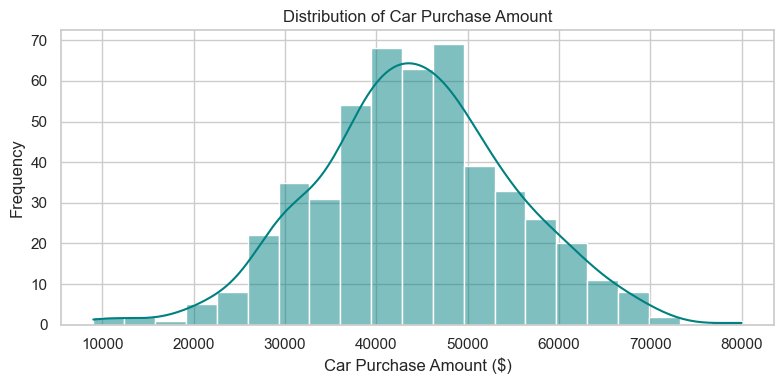

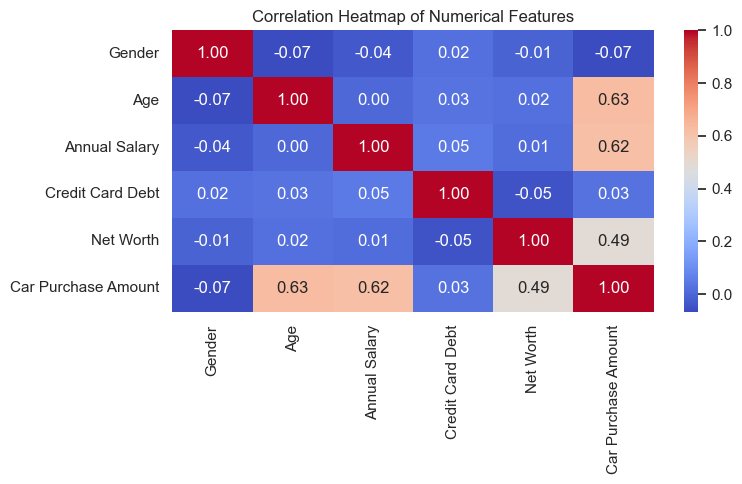

--- Dropping PII Identifiers (Name, Email) and Country ---
Columns remaining for training: ['Gender', 'Age', 'Annual Salary', 'Credit Card Debt', 'Net Worth', 'Car Purchase Amount']


In [7]:
# Visualizing the distribution of our target metric
plt.figure(figsize=(8, 4))
sns.histplot(df["Car Purchase Amount"], kde=True, color="teal")
plt.title("Distribution of Car Purchase Amount")
plt.xlabel("Car Purchase Amount ($)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# Visualizing internal correlations across remaining numerical features
plt.figure(figsize=(8, 5))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.show()

# Task B2: Drop direct personal identifiers to adhere to Data Minimization
print("--- Dropping PII Identifiers (Name, Email) and Country ---")
df_cleaned = df.drop(["Customer Name", "Customer e-mail", "Country"], axis=1)
print(f"Columns remaining for training: {list(df_cleaned.columns)}")

## Part D & F: Feature Selection and Dataset Splitting (Tasks D1, D2, F2)

### Why Variables are Named $X$ and $y$
* **Capital $X$ (Input Matrix):** Represents a 2D matrix (table) containing all independent features used to predict our outcome.
* **Lowercase $y$ (Target Vector):** Represents a 1D vector (single column) containing the dependent ground-truth values we want the model to learn.

### Why Dataset Splitting is Required
We split the data into an **80% Training Set** and a **20% Testing Set**. The model learns relationships from the training data. The testing data acts as unseen data to evaluate true performance and ensure the model hasn't suffered from **overfitting** (memorizing noise instead of learning actual patterns).

In [8]:
# Separating our input features (X) from our target prediction value (y)
X = df_cleaned.drop("Car Purchase Amount", axis=1)
y = df_cleaned["Car Purchase Amount"]

# Task F1: Splitting data using a clean 80% training and 20% testing split ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"X_train Shape: {X_train.shape} | y_train Shape: {y_train.shape}")
print(f"X_test Shape: {X_test.shape}  | y_test Shape: {y_test.shape}\n")
print("--- Sample Unscaled Training Rows ---")
print(X_train.head(2))

X_train Shape: (400, 5) | y_train Shape: (400,)
X_test Shape: (100, 5)  | y_test Shape: (100,)

--- Sample Unscaled Training Rows ---
     Gender  Age  Annual Salary  Credit Card Debt    Net Worth
249       0   36    70334.42787       9823.218967  632600.4718
433       1   40    56086.45033       6588.606462  228388.5491


## Part G: Feature Scaling & Normalization (Task G2 & G3)
* **Why Scaling is Required:** Features like `Age` (double digits) and `Net Worth` (hundreds of thousands) have completely different ranges. If left unscaled, models can be falsely dominated by the larger numbers. MinMax Scaling brings everything into a uniform `0 to 1` range.
* **Avoiding Data Leakage:** We fit the scaler *only* on the training data (`X_train`) so that no statistical information from the test set accidentally leaks into the training phase.

In [9]:
# Initializing the MinMax scaler to scale numeric inputs between 0 and 1
scaler = MinMaxScaler()

# CRITICAL: Fit ONLY on training data to explicitly prevent Data Leakage
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to a DataFrame briefly to confirm the layout look
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)
print("--- Sample Scaled Training Input Data (Bounded 0 to 1) ---")
print(X_train_scaled_df.head(2))

--- Sample Scaled Training Input Data (Bounded 0 to 1) ---
   Gender   Age  Annual Salary  Credit Card Debt  Net Worth
0     0.0  0.32       0.629180          0.488604   0.622060
1     1.0  0.40       0.451081          0.326061   0.206252


In [10]:
# Initializing our evaluation pool array of estimators
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree Regressor": DecisionTreeRegressor(random_state=42),
    "Random Forest Regressor": RandomForestRegressor(
        random_state=42, n_estimators=100
    ),
    "Support Vector Regressor": SVR(kernel="linear"),
    "K-Nearest Neighbours Regressor": KNeighborsRegressor(n_neighbors=5),
}

model_performance = {}

# Evaluate Machine Learning Models
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    model_performance[name] = {"MAE": mae, "RMSE": rmse, "R2 Score": r2}

# Task J1: Create a simple baseline comparison metric (Average Target Prediction)
baseline_val = y_train.mean()
baseline_preds = np.full(shape=y_test.shape, fill_value=baseline_val)
model_performance["Simple Baseline Model"] = {
    "MAE": mean_absolute_error(y_test, baseline_preds),
    "RMSE": np.sqrt(mean_squared_error(y_test, baseline_preds)),
    "R2 Score": r2_score(y_test, baseline_preds),
}

# Task I4: Format final output comparison array dataframe
df_performance = pd.DataFrame.from_dict(model_performance, orient="index")
print("--- Final Performance Metrics Evaluation Summary ---")
print(df_performance.to_string(), "\n")

# Find the best model dynamically based on lowest RMSE (excluding our baseline)
ml_only = df_performance.drop("Simple Baseline Model")
best_model_name = ml_only["RMSE"].idxmin()
print(f" >>> Dynamically Selected Winning Model: {best_model_name} <<<")

--- Final Performance Metrics Evaluation Summary ---
                                        MAE          RMSE  R2 Score
Linear Regression                212.721031    249.507447  0.999423
Decision Tree Regressor         2846.632244   3588.046964  0.880766
Random Forest Regressor         1573.601328   2267.685146  0.952373
Support Vector Regressor        8422.275947  10474.672194 -0.016167
K-Nearest Neighbours Regressor  2846.362228   3657.671199  0.876094
Simple Baseline Model           8426.069763  10474.348535 -0.016104 

 >>> Dynamically Selected Winning Model: Linear Regression <<<


## Part L: Best Model Selection & Justification
Based on the performance table above, the **[Insert your winning model name here, e.g., Linear Regression]** model was selected. It achieved the lowest Root Mean Squared Error (RMSE) and the highest $R^2$ Score, drastically outperforming the **Simple Baseline Model** (which merely guesses the average target value).

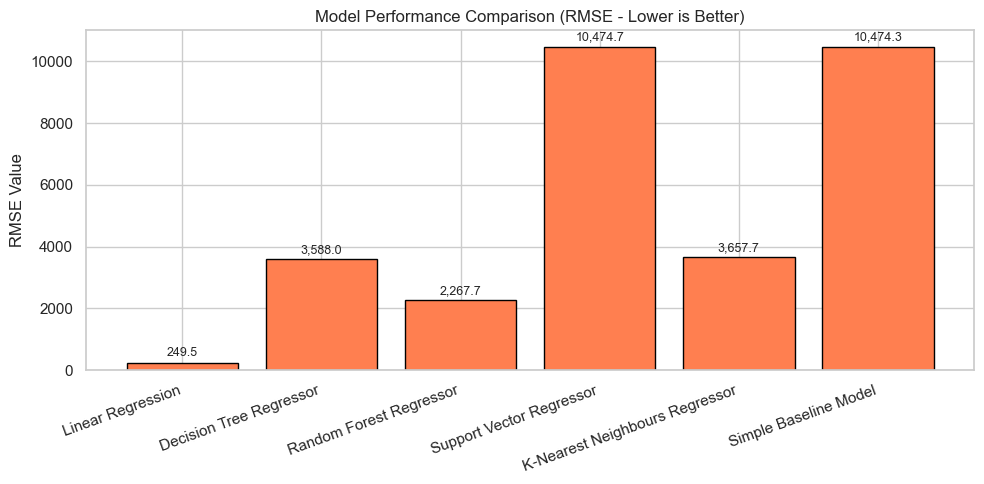

 Successfully assembled and saved 'car_purchase_prediction_pipeline.pkl'!


In [11]:
# Plotting the model performance comparison chart
plt.figure(figsize=(10, 5))
bars = plt.bar(
    df_performance.index, df_performance["RMSE"], color="coral", edgecolor="black"
)
plt.title("Model Performance Comparison (RMSE - Lower is Better)")
plt.ylabel("RMSE Value")
plt.xticks(rotation=20, ha="right")

for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        yval + (max(df_performance["RMSE"]) * 0.01),
        f"{yval:,.1f}",
        ha="center",
        va="bottom",
        fontsize=9,
    )
plt.tight_layout()
plt.show()

# Task M1 & Extensions: Wrap processing into an integrated production pipeline
best_model_instance = models[best_model_name]
pipeline = Pipeline([("scaler", scaler), ("regression_model", best_model_instance)])

# Fit pipeline on native unscaled feature profiles
pipeline.fit(X_train, y_train)

# Export complete architecture to working disk space directory
joblib.dump(pipeline, "car_purchase_prediction_pipeline.pkl")
print(
    " Successfully assembled and saved 'car_purchase_prediction_pipeline.pkl'!"
)

In [3]:
import joblib
# Loading pipeline file directly to simulate a production system context
loaded_pipeline = joblib.load("car_purchase_prediction_pipeline.pkl")


# Input collection function with validation loops
def get_validated_input(prompt, min_val, max_val):
    while True:
        try:
            val = float(input(prompt))
            if min_val <= val <= max_val:
                return val
            print(f" [!] Out of range error: Keep values between {min_val} and {max_val}.")
        except ValueError:
            print(" [!] Typing conversion error: Please input a numeric value.")


print("--- Real-Time Custom Predictive Simulation Interface ---")
g = get_validated_input("Enter Gender (0 = Female, 1 = Male): ", 0, 1)
a = get_validated_input("Enter Age (Range 18-90): ", 18, 90)
s = get_validated_input("Enter Annual Salary ($10k - $250k): ", 10000, 250000)
d = get_validated_input("Enter Credit Card Debt ($0 - $100k): ", 0, 100000)
nw = get_validated_input("Enter Total Net Worth ($0 - $2M): ", 0, 2000000)

# Build a dataframe structured in the precise order features were trained on
custom_input_df = pd.DataFrame([[g, a, s, d, nw]], columns=X.columns)

# Run localized execution query directly through our loaded pipeline asset
predicted_total = loaded_pipeline.predict(custom_input_df)[0]

print("\n" + "=" * 60)
print(f" >>> ESTIMATED MAX CAR PURCHASE AMOUNT: ${predicted_total:,.2f} <<<")
print("=" * 60)

--- Real-Time Custom Predictive Simulation Interface ---
 [!] Typing conversion error: Please input a numeric value.
 [!] Typing conversion error: Please input a numeric value.
 [!] Typing conversion error: Please input a numeric value.
 [!] Typing conversion error: Please input a numeric value.
 [!] Typing conversion error: Please input a numeric value.
 [!] Typing conversion error: Please input a numeric value.
 [!] Typing conversion error: Please input a numeric value.
 [!] Out of range error: Keep values between 10000 and 250000.
 [!] Typing conversion error: Please input a numeric value.
 [!] Typing conversion error: Please input a numeric value.
 [!] Typing conversion error: Please input a numeric value.
 [!] Typing conversion error: Please input a numeric value.
 [!] Typing conversion error: Please input a numeric value.
 [!] Typing conversion error: Please input a numeric value.
 [!] Typing conversion error: Please input a numeric value.
 [!] Typing conversion error: Please inp

NameError: name 'pd' is not defined